In [1]:
# Single-Layer Support Vector Machine (SVM) for Multi-Class Classification 

IMPORT LIBRARIES

In [2]:
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

CLASS SVM

Iteration 0: loss 2.0042474982201464
Iteration 30: loss 0.6828802656749158
Iteration 60: loss 0.46760392171015347
Iteration 90: loss 0.37513804125618516
Iteration 120: loss 0.11195118869198922
Iteration 150: loss 0.23454673741756038
Iteration 180: loss 0.014831446793426354

Predictions [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 1 2 2 2 0 0]
Actual [1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0]

Accuracy: 0.9666666666666667

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      1.00      0.95         9
           2       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



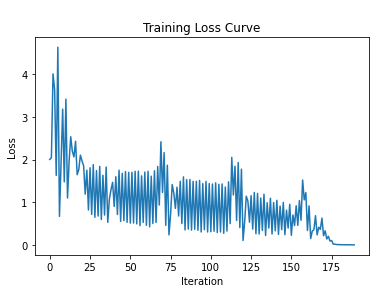

In [3]:
class SVM:
    def __init__(self):
        
        self.W=None
        self.b=None
        self.X_updated=None
        self.batch_size=None
        self.loss_history=[]
        
   #--------------------------------------------LOSS FUNCTION----------------------------------------------------------
    def multi_class_SVM_Loss(self,X,y):
        num_train=X.shape[0]
   
        #multiply weights with inputs
        scores=self.W.dot(X.T) 
        #add bias to with each neuron output
        scores=scores.T+self.b
        #scores have shape (num_examples,classes)

        #find correct scores (scores of actual class)
        correct_scores=scores[np.arange(num_train),y.flatten()].reshape(-1, 1)

        #subtract actual class score from every other class output + delta
        margins=np.maximum(0, scores -correct_scores + 1)
        #at place of actual class score make it 0
        margins[np.arange(num_train),y.flatten()]=0
        
        #find loss( summation across columns for each example and than div by num of examples)
        loss = np.mean(np.sum(margins,axis=1))
        
        return loss
        
    #------------------------------------------TRAIN FUNCTION-------------------------------------------------------------
    def train(self,X,y,learning_rate=0.01, num_iters=500, batch_size=50):
        
        self.X_updated=X
        self.batch_size=batch_size
        
        #store number of rows and columns
        num_train=X.shape[0]
        dim=X.shape[1]
        
        num_classes=len(np.unique(y))
        
        #RANDOM WEIGHTS
        self.W=0.001*np.random.randn(num_classes,dim)
        
        #RANDOM BIAS VECTOR
        self.b=np.zeros(num_classes).reshape(1,-1) 

        y=y.reshape(1,-1)  

        for iteration in range(num_iters):
            #loss calculation
            loss=self.multi_class_SVM_Loss(X, y)
            if iteration %30==0:
                print(f"Iteration {iteration}: loss {loss}")

            self.loss_history.append(loss)
            
            #gradient descent
            self.gradient_descent(X,y,learning_rate)
        
        
    #----------------------------------------------PARAMETERS UPDATE-------------------------------------------------------
    def gradient_descent(self,X,y,lr):
        
        #call derivatives function wrt each parameter
        dW, db,dx = self.derivatives(X, y)
        
        #UPDATE PARAMETERS
        self.W -=lr*dW
        self.b -= lr*db
        self.X_updated-=lr*dx
        
    
    #---------------------------------------------DERIVATIVE FUNCION------------------------------------------------------
    def derivatives(self,X,y):
        # Compute gradients
        
        #multiply weights with inputs
        scores=self.W.dot(X.T) 
        #add bias to with each neuron output
        scores=scores.T+self.b
        #scores have shape (num_examples,classes)
        
        #find correct scores (scores of actual class)
        correct_scores=scores[np.arange(self.batch_size),y.flatten()].reshape(-1,1)
        
        #subtract actual class score from every other class output
        margins=np.maximum(0, scores - correct_scores + 1)
        margins[np.arange(self.batch_size),y]=0
        
        #create mask of true and false
        binary=margins>0
        #make 1 where loss is greater than 0
        binary=binary.astype(int)
        
        #perform summation across columns 
        row_sum=np.sum(binary, axis=1)
        #make sum of each row with negative sign as the score of origional class
        binary[np.arange(self.batch_size),y.flatten()] = -row_sum
        
        #derivative wrt weights
        dW =np.dot(binary.T,X)
        
        #derivative wrt bias
        db=np.sum(binary, axis=0).reshape(1,-1)  
        
        #derivative wrt x
        dx=np.dot(self.W.T,binary.T).T
        
        return dW,db,dx
    
    #---------------------------------------------------RETURN WEIGHTS-----------------------------------------------------
    def get_weights_bias(self):
        return self.W,self.b
    
    #-----------------------------------------------------PREDICTION-------------------------------------------------------
    # Function to predict labels
    def predict(self,X, W, b):
        scores=W.dot(X.T)  
        scores=scores.T+b
        #FIND INDEXES OF CLASSES THAT GIVES MAX SCORE 
        y_pred=np.argmax(scores, axis=1)
        return y_pred
    
#---------------------------------------------------------MAIN-------------------------------------------------------------
#LOAD IRIS DATASET
iris=datasets.load_iris()
X=iris.data
y=iris.target

#SPLIT DATA IN TRAIN AND TEST
X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

#MAKE OBJECT OF SVM CLASS AND TRAIN MODEL
svm_model=SVM()
svm_model.train(X_train, y_train,learning_rate=0.001, num_iters=190, batch_size=X_train.shape[0])
weights,bias=svm_model.get_weights_bias()

#PREDICTIONS
y_pred = svm_model.predict(X_test,weights,bias)
print("\nPredictions", y_pred)
print("Actual", y_test)

#ACCURACY SCORE
accuracy = accuracy_score(y_test, y_pred)
print("\nAccuracy:", accuracy)


#CLASSIFICATION REPORT
report = classification_report(y_test, y_pred)

print("\nClassification Report:")
print(report)


#TRAIN CURVE
plt.plot(range(len(svm_model.loss_history)), svm_model.loss_history)
plt.title('\nTraining Loss Curve')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.show()